# 1D Convulational Autoencoder

The idea of a reconstruction autoencoder:

1. squeeze a window of 234 samples into a handful of numbers (the latent code),
2. rebuild the window from those numbers only,
3. train the model to make the rebuilt window match the original one.

Train it only on normal beats. It then becomes very good at rebuilding normal beats
and stays bad at rebuilding anything else, because it never learned what "anything else"
looks like. The size of that gap is the anomaly score.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch

from m1_defect_anomaly_2026.beats import load_split
from m1_defect_anomaly_2026.splits import DS1_train, DS2_test
from m1_defect_anomaly_2026.preprocessing import FS
from m1_defect_anomaly_2026.evaluation import (evaluate_scores, select_threshold,
                                               build_table, save_table)
from m1_defect_anomaly_2026.autoencoders import (Conv1dAutoencoder, beat_windows,
                                                 beat_window_starts, split_records,
                                                 stack_windows, train_autoencoder,
                                                 reconstruct, squared_error,
                                                 reconstruction_error, percentile_threshold,
                                                 threshold_sweep, error_curve, set_seed)

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA = str(REPO_ROOT / "data" / "raw")
RESULTS_DIR = Path("../results/autoencoders")
FIG_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
set_seed(SEED)
print("torch", torch.__version__, "| threads:", torch.get_num_threads())

torch 2.13.0+cpu | threads: 1


## 1 - The data 

Same split as everywhere else in the project: DS1 to build the model, DS2 to measure it,
and no patient on both sides.

Inside DS1 we go one step further and put 5 whole records aside. Those records are
never seen during training and are used only to choose the threshold. Choosing the
threshold on records the model was trained on would give an error distribution that is
too optimistic, and the threshold would end up too low.

In [2]:
ds1 = load_split(DS1_train, DATA)
ds2 = load_split(DS2_test, DATA)

print(f"DS1: {len(ds1)} records, {sum(r.n_beats for r in ds1):,} beats")
print(f"DS2: {len(ds2)} records, {sum(r.n_beats for r in ds2):,} beats")

DS1: 22 records, 51,003 beats
DS2: 22 records, 49,692 beats


In [3]:
train_records, val_records = split_records(ds1, n_val=5, seed=SEED)
print("training records  :", [r.name for r in train_records])
print("validation records:", [r.name for r in val_records])

# the model only ever sees normal beats
X_train, meta_train = stack_windows(train_records, beat_windows, normal_only=True)
X_val, meta_val = stack_windows(val_records, beat_windows, normal_only=True)

# the validation records with their anomalies too, to compare threshold rules later
X_val_all, meta_val_all = stack_windows(val_records, beat_windows, normal_only=False)

# the test set is untouched: every DS2 beat, normal or not
X_test, meta_test = stack_windows(ds2, beat_windows, normal_only=False)
y_test = meta_test["y"].to_numpy()

print()
print("train windows (normal only):", X_train.shape)
print("val windows   (normal only):", X_val.shape)
print("test windows  (all of DS2) :", X_test.shape,
      "- anomaly rate", round(float(y_test.mean()), 3))
print()
print("one window =", X_train.shape[1], "samples =",
      round(X_train.shape[1] / FS, 2), "seconds around the R peak")

training records  : ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '124', '203', '205', '207', '215', '220', '223']
validation records: ['122', '201', '208', '209', '230']

train windows (normal only): (35280, 234)
val windows   (normal only): (10569, 234)
test windows  (all of DS2) : (49692, 234) - anomaly rate 0.11

one window = 234 samples = 0.65 seconds around the R peak


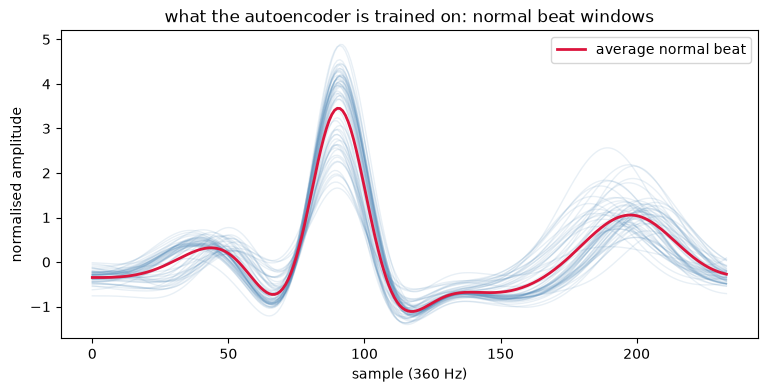

In [5]:
plt.figure(figsize=(9, 4))
for i in range(0, 3000, 50):
    plt.plot(X_train[i], color="steelblue", alpha=0.12, lw=1)
plt.plot(X_train[:3000].mean(axis=0), color="crimson", lw=2, label="average normal beat")
plt.title("what the autoencoder is trained on: normal beat windows")
plt.xlabel("sample (360 Hz)")
plt.ylabel("normalised amplitude")
plt.legend()
plt.savefig(FIG_DIR / "training_windows.png")

All the beats line up on the big spike because the window is cut right on the R peak, but everything after it spreads out a lot. So "normal" is not one single shape, and the red average is already flatter than any real beat.

## 2 - The model

Three convolutions with stride 2 read the window through small sliding filters and halve
its length each time: 234 -> 117 -> 59 -> 30. Then one `Linear` layer squeezes everything
into 16 numbers, and the decoder does the reverse.

Those 16 numbers are the whole point. A model with a wide middle layer can simply copy its input, and would then rebuild abnormal beats just as well as normal ones - which would destroy the anomaly score. With 16 numbers for 234 samples it has to learn a summary of what a normal beat looks like.

In [6]:
set_seed(SEED)
model = Conv1dAutoencoder(input_length=X_train.shape[1], latent_dim=16)

print(model)
print()
print("input length      :", model.input_length, "samples")
print("bottleneck        :", model.latent_dim, "numbers per beat",
      f"({model.input_length / model.latent_dim:.0f}x compression)")
print("parameters        :", f"{sum(p.numel() for p in model.parameters()):,}")

Conv1dAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (3): ReLU()
    (4): Conv1d(32, 64, kernel_size=(7,), stride=(2,), padding=(3,))
    (5): ReLU()
  )
  (to_latent): Linear(in_features=1920, out_features=16, bias=True)
  (from_latent): Linear(in_features=16, out_features=1920, bias=True)
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv1d(64, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (2): ReLU()
    (3): Upsample(scale_factor=2.0, mode='nearest')
    (4): Conv1d(32, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): ReLU()
    (6): Upsample(scale_factor=2.0, mode='nearest')
    (7): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (8): ReLU()
    (9): Conv1d(16, 1, kernel_size=(7,), stride=(1,), padding=(3,))
  )
)

input length      : 234 samples
bottleneck       

In [7]:
start = time.time()
history = train_autoencoder(model, X_train, X_val,
                            epochs=30, batch_size=256, lr=1e-3,
                            patience=5, seed=SEED, verbose=True)
print(f"\ntraining took {time.time() - start:.0f} s")

epoch   1/30  train 0.16979  val 0.03530
epoch   2/30  train 0.00775  val 0.01082
epoch   3/30  train 0.00332  val 0.00562
epoch   4/30  train 0.00214  val 0.00515
epoch   5/30  train 0.00151  val 0.00327
epoch   6/30  train 0.00123  val 0.00273
epoch   7/30  train 0.00101  val 0.00222
epoch   8/30  train 0.00120  val 0.00191
epoch   9/30  train 0.00064  val 0.00164
epoch  10/30  train 0.00060  val 0.00143
epoch  11/30  train 0.00072  val 0.00151
epoch  12/30  train 0.00056  val 0.00140
epoch  13/30  train 0.00068  val 0.00122
epoch  14/30  train 0.00043  val 0.00130
epoch  15/30  train 0.00058  val 0.00132
epoch  16/30  train 0.00045  val 0.00119
epoch  17/30  train 0.00076  val 0.00114
epoch  18/30  train 0.00038  val 0.00136
epoch  19/30  train 0.00044  val 0.00171
epoch  20/30  train 0.00063  val 0.00118
epoch  21/30  train 0.00047  val 0.00138
epoch  22/30  train 0.00033  val 0.00108
epoch  23/30  train 0.00051  val 0.00109
epoch  24/30  train 0.00042  val 0.00093
epoch  25/30  tr

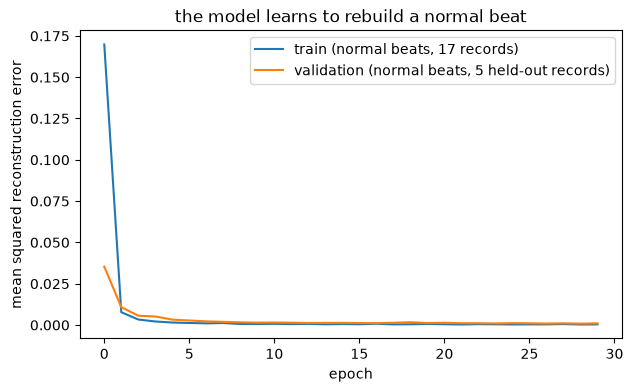

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(history["train"], label="train (normal beats, 17 records)")
plt.plot(history["val"], label="validation (normal beats, 5 held-out records)")
plt.xlabel("epoch")
plt.ylabel("mean squared reconstruction error")
plt.title("the model learns to rebuild a normal beat")
plt.legend()
plt.savefig(FIG_DIR / "cnn_training_curve.png", dpi=150, bbox_inches="tight")

Both curves fall almost to zero in the first two epochs and stay flat after that, so the model learns a normal beat very quickly. Validation starts below train only because the train loss is averaged over the whole epoch, including the bad first batches, while validation is measured once at the end of it.

## 3 - What the model rebuilds

The clearest way to check that the idea works: take one beat of each class, show the
original and the reconstruction on top of each other. If the score means anything, the N
beat should be rebuilt almost perfectly and the V beat should not.

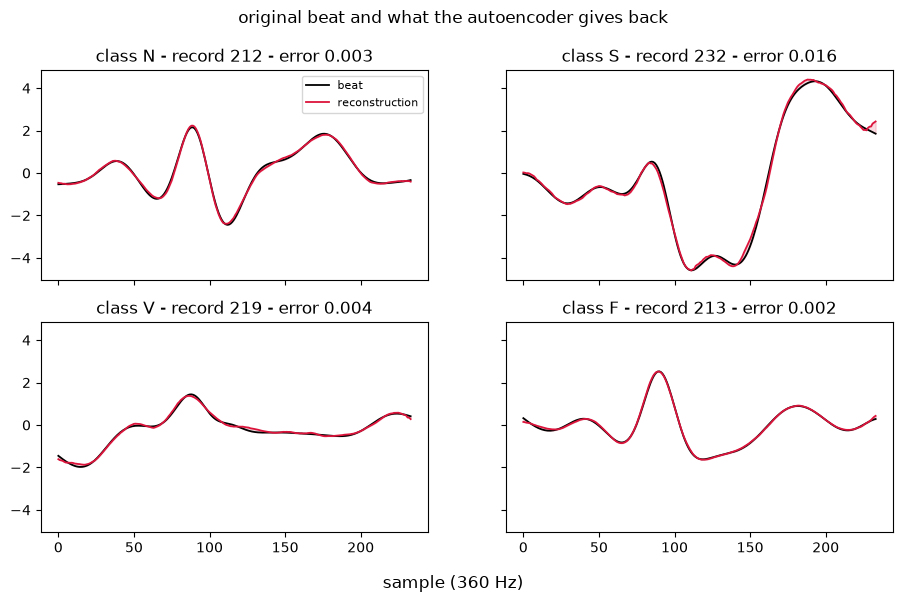

In [9]:
labels_test = meta_test["label"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)
for ax, cls in zip(axes.ravel(), ["N", "S", "V", "F"]):
    rows = np.flatnonzero(labels_test == cls)
    if len(rows) == 0:
        ax.set_visible(False)
        continue
    i = rows[len(rows) // 2]
    original = X_test[i]
    rebuilt = reconstruct(model, X_test[i:i + 1])[0]
    error = float(((original - rebuilt) ** 2).mean())

    ax.plot(original, color="black", lw=1.3, label="beat")
    ax.plot(rebuilt, color="crimson", lw=1.3, label="reconstruction")
    ax.fill_between(np.arange(len(original)), original, rebuilt,
                    color="crimson", alpha=0.15)
    ax.set_title(f"class {cls} - record {meta_test['record'].iloc[i]} - error {error:.3f}")

axes[0, 0].legend(loc="upper right", fontsize=8)
fig.supxlabel("sample (360 Hz)")
fig.suptitle("original beat and what the autoencoder gives back")
fig.savefig(FIG_DIR / "cnn_reconstructions.png", dpi=150, bbox_inches="tight")

The model rebuilds all four beats almost perfectly, and the V beat (0.004) is barely worse than the normal one (0.003). Only the S beat stands out, and mostly because it is simply a much taller beat, so a big beat gives a big error even when the shape is right.

## 4 - The reconstruction error as a score

One number per beat: the mean squared error over the 234 samples of its window. High
error = the model could not rebuild it = anomaly.

median error, normal beats   : 0.0006
median error, abnormal beats : 0.0021


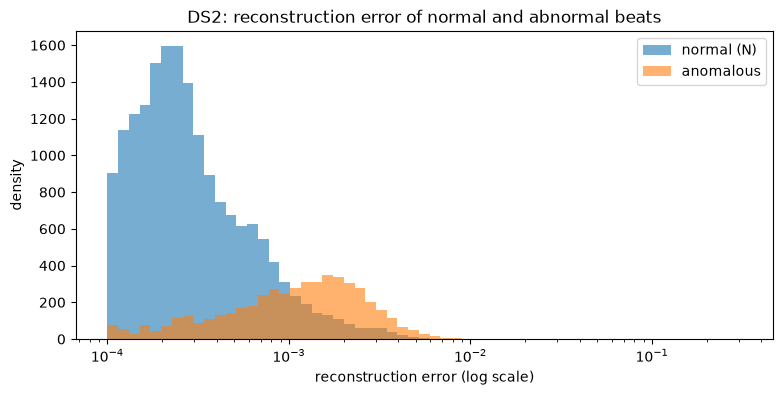

In [10]:
val_scores = reconstruction_error(model, X_val)          # normal beats, held-out records
test_scores = reconstruction_error(model, X_test)        # every DS2 beat

plt.figure(figsize=(9, 4))
low = max(float(test_scores.min()), 1e-4)
bins = np.logspace(np.log10(low), np.log10(float(test_scores.max())), 60)
plt.hist(test_scores[y_test == 0], bins=bins, alpha=0.6, density=True, label="normal (N)")
plt.hist(test_scores[y_test == 1], bins=bins, alpha=0.6, density=True, label="anomalous")
plt.xscale("log")
plt.xlabel("reconstruction error (log scale)")
plt.ylabel("density")
plt.title("DS2: reconstruction error of normal and abnormal beats")
plt.legend()
plt.savefig(FIG_DIR / "cnn_error_distribution.png", dpi=150, bbox_inches="tight")

print("median error, normal beats   :", round(float(np.median(test_scores[y_test == 0])), 4))
print("median error, abnormal beats :", round(float(np.median(test_scores[y_test == 1])), 4))

The abnormal beats sit about three times higher than the normal ones (median 0.0021 against 0.0006), so the error does carry real information. But the two humps overlap heavily: most abnormal beats fall inside the range where normal beats also live, and only the far right tail above roughly 0.005 is clean.

## 5 - Choosing the threshold

The threshold is the real decision boundary, so it deserves more care than the architecture. The rule used here needs no anomaly label: take the reconstruction error of the normal beats of the held-out validation records and keep a high percentile of it.


In [11]:
sweep = threshold_sweep(val_scores, y_test, test_scores,
                        percentiles=(90.0, 95.0, 97.5, 99.0, 99.5))
sweep.round(4)

,percentile,threshold,precision,recall,f1,fp,fn
0,90.0,0.0016,0.2942,0.6680,0.4085,8736,1810
1,95.0,0.0022,0.2977,0.4773,0.3667,6138,2850
2,97.5,0.0030,0.2780,0.2766,0.2773,3917,3944
3,99.0,0.0047,0.2988,0.0882,0.1362,1129,4971
4,99.5,0.0068,0.1969,0.0306,0.0530,681,5285


In [12]:
PERCENTILE = 99.0

threshold = percentile_threshold(val_scores, PERCENTILE)
cnn_result = evaluate_scores(y_test, test_scores, threshold, "1D CNN autoencoder")

print(f"threshold = {threshold:.4f}  (percentile {PERCENTILE} of the normal validation errors)")
print("precision:", round(cnn_result["precision"], 3))
print("recall   :", round(cnn_result["recall"], 3))
print("F1       :", round(cnn_result["f1"], 3))
print("ROC-AUC  :", round(cnn_result["roc_auc"], 3))

threshold = 0.0047  (percentile 99.0 of the normal validation errors)
precision: 0.299
recall   : 0.088
F1       : 0.136
ROC-AUC  : 0.816


In [13]:
y_val_all = meta_val_all["y"].to_numpy()
val_all_scores = reconstruction_error(model, X_val_all)
f1_threshold, f1_val = select_threshold(y_val_all, val_all_scores)
f1_result = evaluate_scores(y_test, test_scores, f1_threshold, "1D CNN autoencoder (best-F1 threshold)")

print(f"percentile {PERCENTILE} -> threshold {threshold:.4f}, F1 on DS2 {cnn_result['f1']:.3f}")
print(f"best F1 on validation -> threshold {f1_threshold:.4f}, F1 on DS2 {f1_result['f1']:.3f}")
print()
print("ROC-AUC does not depend on the threshold at all:", round(cnn_result["roc_auc"], 3))

percentile 99.0 -> threshold 0.0047, F1 on DS2 0.136
best F1 on validation -> threshold 0.0025, F1 on DS2 0.332

ROC-AUC does not depend on the threshold at all: 0.816


The two thresholds are almost a factor of two apart (0.0047 against 0.0025) and F1 goes from 0.136 to 0.332. So on this model the threshold matters far more than the architecture does. The percentile rule needs no anomaly label and still lands close to the labelled one, around the 95th percentile, which is reassuring.

ROC-AUC stays at 0.816 whatever the threshold, because it reads the whole ranking nstead of one cut point. That is the number to compare with the Isolation Forest (0.836): the autoencoder ranks the beats slightly worse than the 35 features written by hand, even though it had the raw signal to work from.

In [14]:
meta_test = meta_test.copy()
meta_test["score"] = test_scores
meta_test["flag"] = (test_scores >= threshold).astype(int)

anomalies = meta_test[meta_test["y"] == 1]
per_class = anomalies.groupby("label").agg(n_beats=("y", "size"), caught=("flag", "mean"))
print(per_class.round(3).to_string())

       n_beats  caught
label                 
F          388   0.005
Q            7   0.714
S         1837   0.061
V         3220   0.112


Unlike every earlier model, the V beats are not the easy class here the Random Forest caught them at 0.946. The reconstruction error is a squared difference over the window, so it reacts to how big a beat is more than to how wrong its shape is, and a V beat can be completely misshapen without being tall.

The S beats stay low for the reason we expected: the window is cut on the R peak, so it holds the shape of the beat and nothing about when it arrived.

## 6 - Looking at the decisions on the raw signal

Metrics hide what the model actually does. Here the reconstruction is drawn on top of the
real ECG, with the error curve underneath.

The windows overlap, so a sample belongs to more than one beat window. `error_curve()`
averages the values that land on the same sample, which is what makes a continuous curve
out of separate windows. The same function is used twice: once on the reconstructions to
rebuild a continuous signal, once on the squared errors to get the error curve.

In [15]:
# the DS2 record with the most abnormal beats
rec = max(ds2, key=lambda r: int(r.y.sum()))
print("record", rec.name, "-", int(rec.y.sum()), "abnormal beats out of", rec.n_beats)

X_rec = beat_windows(rec)
starts = beat_window_starts(rec)
rebuilt = reconstruct(model, X_rec)
errors = squared_error(model, X_rec)

recon_curve = error_curve(len(rec.signal), starts, rebuilt)
err_curve = error_curve(len(rec.signal), starts, errors)
beat_scores = errors.mean(axis=1)
flagged = beat_scores >= threshold

record 232 - 1382 abnormal beats out of 1780


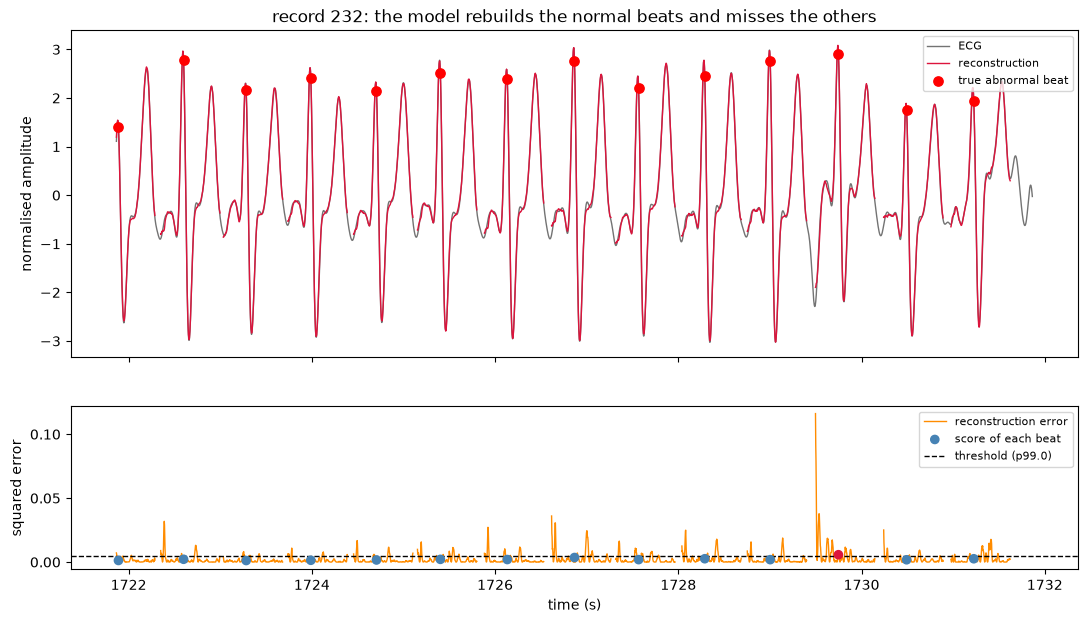

In [16]:
# a 10 second stretch holding as many abnormal beats as possible
span = 10 * FS
best_start, best_count = 0, -1
for peak in rec.r_peaks[rec.y == 1]:
    low = max(0, int(peak) - span // 2)
    count = int(((rec.r_peaks >= low) & (rec.r_peaks < low + span) & (rec.y == 1)).sum())
    if count > best_count:
        best_count, best_start = count, low

low, high = best_start, best_start + span
t = np.arange(low, high) / FS
inside = (rec.r_peaks >= low) & (rec.r_peaks < high)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(t, rec.signal[low:high], color="0.45", lw=1.0, label="ECG")
ax1.plot(t, recon_curve[low:high], color="crimson", lw=1.0, label="reconstruction")
true_peaks = rec.r_peaks[inside & (rec.y == 1)]
ax1.scatter(true_peaks / FS, rec.signal[true_peaks], color="red", s=45, zorder=5,
            label="true abnormal beat")
ax1.set_ylabel("normalised amplitude")
ax1.set_title(f"record {rec.name}: the model rebuilds the normal beats and misses the others")
ax1.legend(loc="upper right", fontsize=8)

ax2.plot(t, err_curve[low:high], color="darkorange", lw=1.0, label="reconstruction error")
# the score of a beat is the average of this curve over its own window, so the threshold
# line is read against the dots, not against the curve
ax2.scatter(rec.r_peaks[inside] / FS, beat_scores[inside],
            c=np.where(flagged[inside], "crimson", "steelblue"), s=35, zorder=5,
            label="score of each beat")
ax2.axhline(threshold, color="black", ls="--", lw=1, label=f"threshold (p{PERCENTILE})")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("squared error")
ax2.legend(loc="upper right", fontsize=8)

fig.savefig(FIG_DIR / "cnn_signal_overlay.png", dpi=150, bbox_inches="tight")

The red reconstruction sits on top of the ECG everywhere, including on the beats marked as abnormal, and the error curve stays flat across all of them. The one clear spike, around 1729 s, is not on a marked beat at all, it is a stretch of noise, so the model's loudest reaction in these ten seconds is a false alarm.

## 7 - Does the model really need the normal-only training set?

Training on normal beats only is a small cheat: to build that training set we had to know
which beats were normal, so a label was used, even if never as a target. This is the same
point that came up with the One-Class SVM in notebook 03.

So here is the honest version: the same model trained on **all** the DS1 beats of the
training records, anomalies included, with no label used anywhere. On MIT-BIH that means
about 11% of the training set is made of the very thing we want to detect.

In [17]:
X_train_all, _ = stack_windows(train_records, beat_windows, normal_only=False)
print("training windows without any label filtering:", X_train_all.shape)

set_seed(SEED)
blind = Conv1dAutoencoder(input_length=X_train_all.shape[1], latent_dim=16)
train_autoencoder(blind, X_train_all, X_val, epochs=30, batch_size=256,
                  lr=1e-3, patience=5, seed=SEED, verbose=False)

blind_val = reconstruction_error(blind, X_val)
blind_test = reconstruction_error(blind, X_test)
blind_threshold = percentile_threshold(blind_val, PERCENTILE)
blind_result = evaluate_scores(y_test, blind_test, blind_threshold,
                               "1D CNN autoencoder (trained on all beats)")

print("normal-only training:  F1", round(cnn_result["f1"], 3),
      " ROC-AUC", round(cnn_result["roc_auc"], 3))
print("no label at all     :  F1", round(blind_result["f1"], 3),
      " ROC-AUC", round(blind_result["roc_auc"], 3))

training windows without any label filtering: (38353, 234)
normal-only training:  F1 0.136  ROC-AUC 0.816
no label at all     :  F1 0.054  ROC-AUC 0.742


Contamination costs about 0.07 of ROC-AUC (0.816 → 0.742). That is a real loss but a mild one, and much smaller than what the One-Class SVM suffered in notebook 03, where the same change moved F1 from 0.877 to 0.275.

The reason is in how the two models use their training data. The SVM draws a boundary around every point it is given, so 11% of abnormal beats stretch the boundary until it swallows them. The autoencoder only minimises an average reconstruction error over 38 353 windows, the abnormal ones are outnumbered nine to one and barely move where the model settles.

## 8 - Results

The two autoencoder rows go into the comparison table next to everything built so far.

In [18]:
previous = pd.read_csv(REPO_ROOT / "results" / "supervised_ml" / "comparison_table.csv")
table = build_table(previous.to_dict("records") + [cnn_result, blind_result])
save_table(table, RESULTS_DIR / "comparison_table.csv", RESULTS_DIR / "comparison_table.md")
table[["method", "precision", "recall", "f1", "roc_auc"]].round(3)

,method,precision,recall,f1,roc_auc
0,Random Forest,0.837,0.633,0.721,0.948
1,XGBoost,0.686,0.677,0.681,0.940
2,Isolation Forest,0.343,0.566,0.427,0.836
3,Spectral features,0.297,0.502,0.373,0.773
4,CUSUM (k=0.5),0.410,0.335,0.369,0.680
5,Z-score (10s window),0.652,0.175,0.276,0.615
6,One-Class SVM,0.200,0.437,0.275,0.687
7,Random baseline,0.110,0.996,0.198,0.500
8,Z-score (1s window),0.110,0.997,0.198,0.274
9,1D CNN autoencoder,0.299,0.088,0.136,0.816


The autoencoder reaches ROC-AUC 0.816, just under the Isolation Forest's 0.836. That is the comparison that matters, because neither model was given an anomaly label, while the Random Forest (0.948) saw every label of DS1.

So learning the representation from the raw signal did not beat the 35 features written by hand. The features encode the RR intervals, which say when a beat arrived; a window cut on the R peak does not, and that is most of the gap.

In [19]:
meta_test.to_parquet(RESULTS_DIR / "cnn_ae_scores_ds2.parquet", index=False)
torch.save(model.state_dict(), RESULTS_DIR / "cnn_autoencoder.pt")
print("saved to", RESULTS_DIR.resolve())

saved to /workspaces/2026-m1-internship-defect-detection/results/autoencoders
